In [4]:
print( "\n Task-2 :- Cleaning Data \n")


 Task-2 :- Cleaning Data 



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("AB_NYC_2019.csv")

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [6]:
df.shape

(48895, 16)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [8]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
df.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


In [13]:
df['name'] = df['name'].fillna("Unknown")

df['host_name'] = df['host_name'].fillna("Unknown")

df['reviews_per_month'] = df['reviews_per_month'].fillna(
    df['reviews_per_month'].mean()
)

In [14]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [16]:
df['neighbourhood_group'] = df['neighbourhood_group'].str.strip()

df['room_type'] = df['room_type'].str.title()

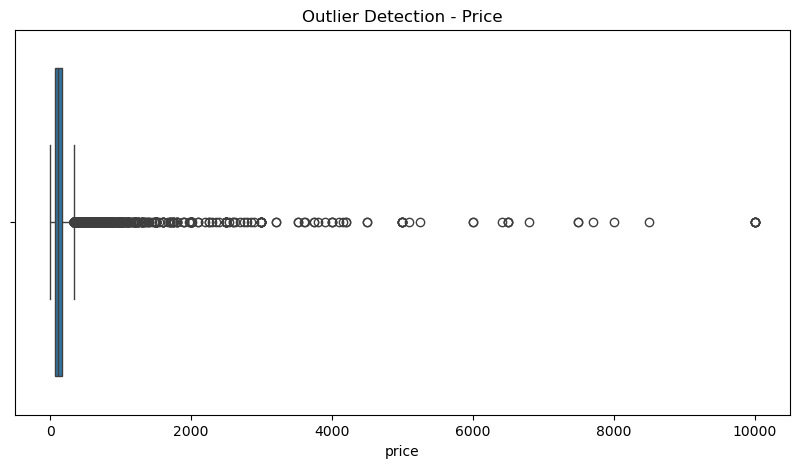

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['price'])

plt.title("Outlier Detection - Price")
plt.show()

In [18]:
Q1 = df['price'].quantile(0.25)

Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower) & (df['price'] <= upper)]

print("Outliers Removed")

Outliers Removed


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45923 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              45923 non-null  int64  
 1   name                            45923 non-null  object 
 2   host_id                         45923 non-null  int64  
 3   host_name                       45923 non-null  object 
 4   neighbourhood_group             45923 non-null  object 
 5   neighbourhood                   45923 non-null  object 
 6   latitude                        45923 non-null  float64
 7   longitude                       45923 non-null  float64
 8   room_type                       45923 non-null  object 
 9   price                           45923 non-null  int64  
 10  minimum_nights                  45923 non-null  int64  
 11  number_of_reviews               45923 non-null  int64  
 12  last_review                     36911

In [20]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.592300e+04,4.592300e+04,45923.000000,45923.000000,45923.000000,45923.000000,45923.000000,45923.000000,45923.000000,45923.000000
mean,1.889853e+07,6.632693e+07,40.728488,-73.950733,119.970320,6.938070,23.942665,1.377222,6.639701,109.378699
std,1.091922e+07,7.755778e+07,0.055331,0.046471,68.150148,19.857823,45.315219,1.516925,31.008148,130.279393
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.436180e+06,7.724081e+06,40.689235,-73.981925,65.000000,1.000000,1.000000,0.270000,1.000000,0.000000
50%,1.952568e+07,3.028359e+07,40.721770,-73.954370,100.000000,2.000000,5.000000,1.180000,1.000000,39.000000
75%,2.891256e+07,1.055068e+08,40.763390,-73.934315,159.000000,5.000000,24.000000,1.620000,2.000000,217.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,334.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


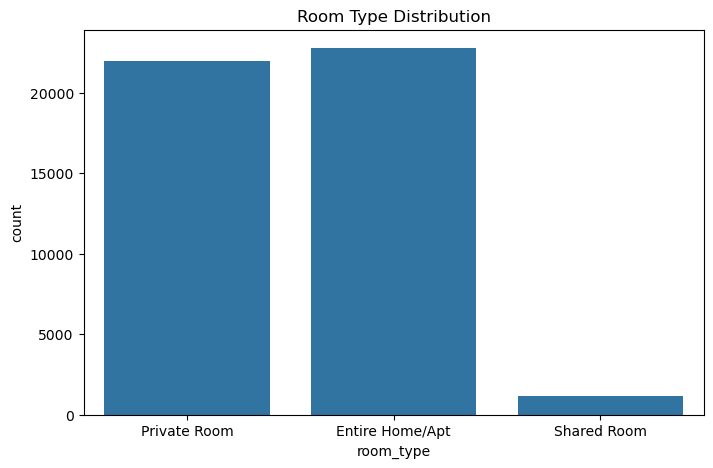

In [23]:
#Room Type Distribution

plt.figure(figsize=(8,5))

sns.countplot(x='room_type', data=df)

plt.title("Room Type Distribution")
plt.show()

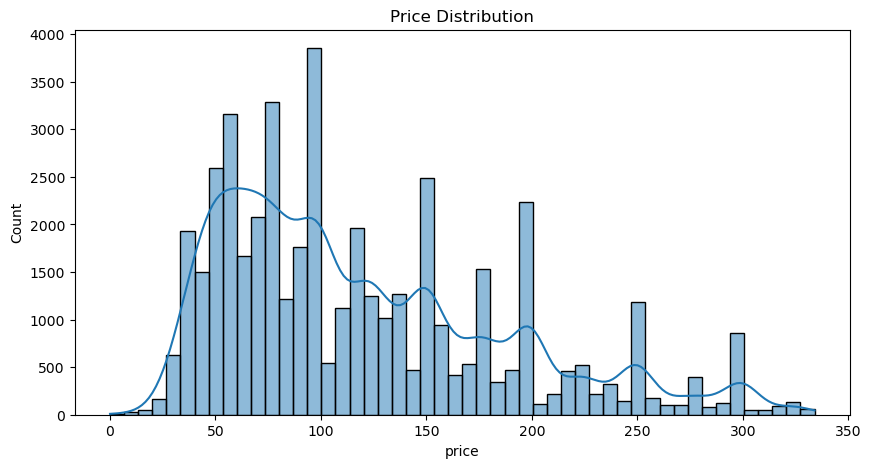

In [24]:
#Price Distribution 

plt.figure(figsize=(10,5))

sns.histplot(df['price'], bins=50, kde=True)

plt.title("Price Distribution")
plt.show()